Systematic Uncertainty Modelling
===

In the `4_nerual_likelihood_ratio_estimation.ipynb` notebook, we left out the nuisance parameter piece of the parameterized density ratio decomposition:

$$\sum_c f_c(\mu) \cdot \nu_c(\mu) \cdot \frac{p_c\left(x\right)}{p_\text{c}(x)} = \mu \cdot \nu_{H \to \tau\tau}(\mu) \cdot  \frac{p_{H \to \tau\tau}\left(x\right)}{p_\text{c}(x)} + \nu_{t\bar{t}}(\mu) \cdot  \frac{p_{t\bar{t}}\left(x\right)}{p_\text{c}(x)} + \nu_{Z \to \tau\tau}(\mu) \cdot  \frac{p_{Z \to \tau\tau}\left(x\right)}{p_\text{c}(x)}$$

The full model is written as

$$\frac{p(x|\mu, \alpha)}{p_{ref}(x)} = \frac{1}{\sum_c G_c(\alpha) \cdot f_c(\mu) \cdot \nu_c} \sum_c f_c(\mu) \cdot G_c(\alpha)\cdot \nu_c \cdot g_c(x|\alpha) \cdot \frac{p_c\left(x\right)}{p_{ref}(x)}$$
where,
$$g_c(x|\alpha) = \frac{p_c(x|\alpha)}{p_\text{c}(x)} $$

HistFactory-style Model
--

The ATLAS NSBI papers [link](https://inspirehep.net/literature/2854620) propose the use of HistFactory-style models in NSBI analysis, to be able to scale the analysis to the large-dimensional nuisance parameter space with sparse simulated basis points typical for ATLAS and CMS experiments. 

This model assumes that **the effect of various independent sources of uncertainty in the likelihood model can be factorized**:

$$g_c(x|\alpha) = \frac{p_c(x|\alpha)}{p_\text{c}(x)} = \prod_p \frac{p_c(x|\alpha_p)}{p_\text{c}(x)}$$

which makes it now another density ratio estimation problem, but instead of training $N_{syst}$ $\alpha_p-$parameterized NNs, we use a HistFactory-style interpolation generalized to a per-event formulation:

$$\frac{p_c(x|\alpha_p)}{p_\text{c}(x)} = \begin{cases}
    \left(\frac{p_c(x|\alpha_p^+)}{p_\text{c}(x)}\right)^{\alpha_p}& \alpha_p>1\\
    1+\sum_{n=1}^6c_n\cdot (\alpha_p)^n& -1\leq\alpha_p\leq 1\\
    \left(\frac{p_c(x|\alpha_p^-)}{p_\text{c}(x)}\right)^{-\alpha_p}& \alpha_p<-1\\
    \end{cases}$$

where $\alpha=\{\alpha_p\}$ and for each nuisance parameter $\alpha_p$, we have three simulation models - $p_\text{c}(x), p_c(x|\alpha_p^+), p_c(x|\alpha_p^-)$. Naturally, this still requires NNs to estimate the density ratios:

$$\frac{p_c(x|\alpha_p^+)}{p_\text{c}(x)} \, , \frac{p_c(x|\alpha_p^-)}{p_\text{c}(x)}$$

**These are the density ratios that we will estimate using NNs in this notebook.**
Two ratios corresponding to each $\alpha_p^\pm$ will be trained for each systematic uncertainty indexed by $p$ and for each channel $c$ to build the final parameterized model, 

$$\frac{p(x|\mu, \alpha)}{p_\text{c}(x)} = \frac{1}{\sum_c G_c(\alpha) \cdot f_c(\mu) \cdot \nu_c} \sum_c f_c(\mu) \cdot G_c(\alpha) \cdot \nu_c \cdot g_c(x|\alpha) \cdot \frac{p_c\left(x\right)}{p_\text{c}(x)}$$

The full workflow for building $\mu, \alpha-$parameterized density ratios is represented in the flowchart below:

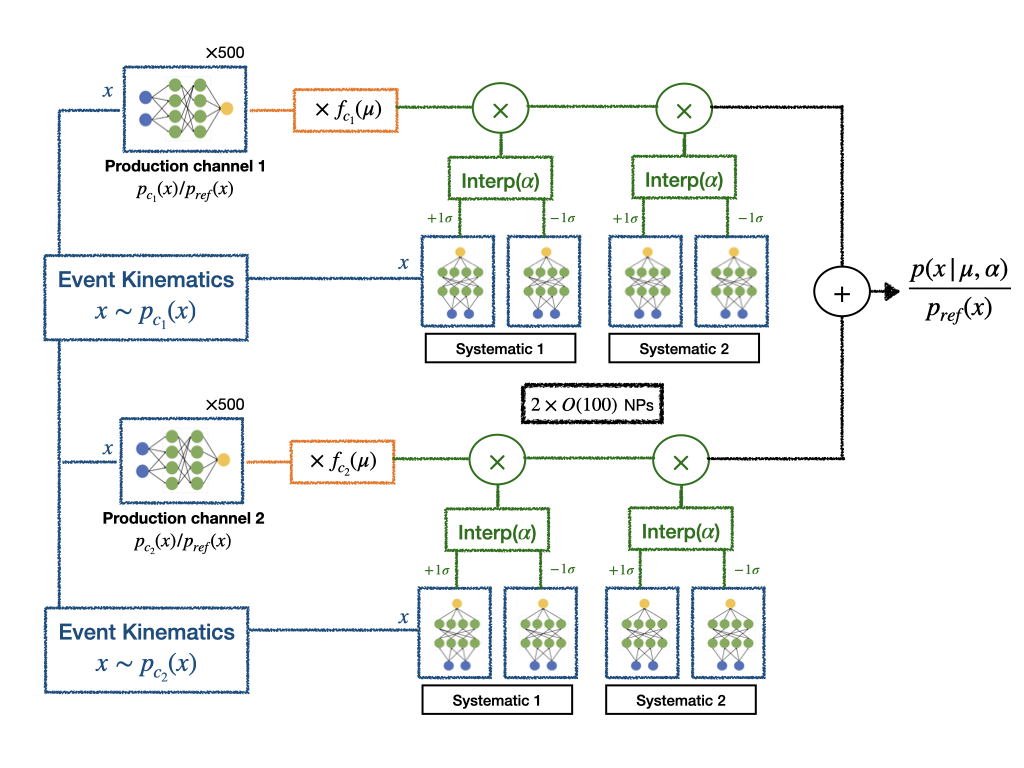

In [21]:
import os
import sys
import argparse
import logging
import numpy as np
import yaml
import warnings
import random 
import mplhep as hep

sys.path.append('../src')
import nsbi_common_utils
from nsbi_common_utils import datasets, configuration
from nsbi_common_utils.training import density_ratio_trainer

hep.style.use(hep.style.ATLAS)

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [22]:
def load_config(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)


In [23]:
workflow_config_path = "./config.pipeline.yaml"

In [24]:
print(f"Loading configuration from {workflow_config_path}")
config_workflow = load_config(workflow_config_path)["systematic_uncertainty"]

nsbi_config_path = config_workflow["nsbi_fit_config"]
print(f"Initializing NSBI ConfigManager from: {nsbi_config_path}")
config_nsbi = nsbi_common_utils.configuration.ConfigManager(file_path_string=nsbi_config_path)


Loading configuration from ./config.pipeline.yaml
Initializing NSBI ConfigManager from: ./config_fit_nsbi.yml


In [25]:
# Input features for training - these features should be the same ones used for nominal training
features, features_scaling = config_nsbi.get_training_features()

print(f"Training features used = \n\n {features}")

Training features used = 

 ['DER_mass_transverse_met_lep', 'log_DER_mass_vis', 'log_DER_pt_h', 'DER_deltar_had_lep', 'log_DER_pt_tot', 'log_DER_sum_pt', 'DER_pt_ratio_lep_had', 'DER_met_phi_centrality']


In [26]:
print("Initializing Datasets...")
branches_to_load = features + ['presel_score']

datasets_helper = nsbi_common_utils.datasets.datasets(
    config_path=nsbi_config_path,
    branches_to_load=branches_to_load
)


# Load the full dataset, including systematic variations defined in the config file
dataset_incl_dict = datasets_helper.load_datasets_from_config(load_systematics=True)

Initializing Datasets...


In [27]:
# Filter out events to get the NSBI signal region 
region = config_workflow["filter_region"]
print(f"Filtering events to be in region {region}")

print(f"Filtering datasets for region: {region}")
dataset_SR_dict = datasets_helper.filter_region_by_type(dataset_incl_dict, region = region)

Filtering events to be in region SR
Filtering datasets for region: SR


In [28]:
path_to_saved_data = config_workflow["saved_data_path"]

Density ratio training
===

Now we train the NNs to predict two ratios,

$$\frac{p_c(x|\alpha_p^+)}{p_\text{c}(x)} \, , \frac{p_c(x|\alpha_p^-)}{p_\text{c}(x)}$$

for each nuisance parameter $\alpha_p$, for each process $p_c$ that is affected by the corresponding nuisance parameter.

Here is a major computational bottleneck of this workflow - for $N_{syst}$ systematics affecting each of the $N_{proc}$ processes, we would need a total of 

$$N_{syst} \times N_{proc} \times 2$$

well-trained NNs. In our example with $N_{syst}=2$ and $N_{proc}=3$, this corresponds to a total of 12 NNs. Typically in LHC experiments $N_{syst}\approx O(10^2)$! This type of approach thus requires a GPU infrastructure for efficient optimizations.

In [29]:
# Load training settings directly from pipeline config
sys_training_params = config_workflow["training_settings"].copy()

print(sys_training_params)

{'hidden_layers': 4, 'neurons': 1000, 'number_of_epochs': 50, 'batch_size': 10000, 'learning_rate': 0.0001, 'scalerType': 'MinMax', 'calibration': True, 'recalibrate_output': True, 'type_of_calibration': 'histogram', 'num_bins_cal': 50, 'callback': True, 'callback_patience': 50, 'callback_factor': 0.5, 'validation_split': 0.2, 'holdout_split': 0.2, 'verbose': 0, 'plot_scaled_features': False, 'load_trained_models': False, 'num_workers': 4}


In [32]:
# Force training override
sys_training_params['load_trained_models'] = True

sys_training_params['ensemble_index'] = None

NN_training_syst_process  = {}
path_to_figures           = {}
path_to_models            = {}

In [33]:
for process in config_nsbi.get_basis_samples():
            
    NN_training_syst_process[process] = {}
    path_to_figures[process]          = {}
    path_to_models[process]           = {}
    
    # Iterate through systematics defined in NSBI config
    for dict_syst in config_nsbi.config["Systematics"]:

        if (process not in dict_syst["Samples"]) or (dict_syst["Type"] != "NormPlusShape"): continue

        syst = dict_syst["Name"]
        NN_training_syst_process[process][syst] = {}
        path_to_figures[process][syst]          = {}
        path_to_models[process][syst]           = {}

        for direction in ["Up", "Dn"]:
            samples_to_train = config_nsbi.get_samples_in_syst_for_training(syst, direction)

            syst_key_name = f"{syst}_{direction}"
            if syst_key_name not in dataset_SR_dict: continue

            print(f"Initializing Trainer: {process} vs {syst_key_name}")

            # Prepare Dataset: Ratio of Systematic / Nominal 
            dataset_syst_nom = datasets_helper.prepare_basis_training_dataset(
                dataset_SR_dict[syst_key_name], 
                [process], 
                dataset_SR_dict["Nominal"], 
                [process]
            )

            # Get the path where trained models will be saved
            training_output_dir_name = config_workflow["output_training_dir"]
            training_output_path = os.path.join(path_to_saved_data, training_output_dir_name)
            if not training_output_path.endswith('/'):
                training_output_path += '/'

            print(f"Training output path: {training_output_path}")
            
            output_name = f'{process}_{syst}_{direction}'
            
            path_to_figures[process][syst][direction]   = os.path.join(training_output_path, f'output_figures_{output_name}/')
            path_to_models[process][syst][direction]    = os.path.join(training_output_path, f'output_model_params_{output_name}/')
            
            NN_training_syst_process[process][syst][direction] = nsbi_common_utils.training.density_ratio_trainer(
                dataset_syst_nom, 
                dataset_syst_nom['weights_normed'].to_numpy(),
                dataset_syst_nom['train_labels'].to_numpy(),
                features, 
                features_scaling,
                [syst+'_'+direction, process], 
                output_name, 
                path_to_figures=path_to_figures[process][syst][direction],
                path_to_models=path_to_models[process][syst][direction],
                delete_existing_models=False
            )

            print(f"Training: {process} | {syst} | {direction}")
            NN_training_syst_process[process][syst][direction].train(**sys_training_params)

            NN_training_syst_process[process][syst][direction].test_normalization()
    

Initializing Trainer: ztautau vs JES_Up
ERROR! Session/line number was not unique in database. History logging moved to new session 1136
Training output path: saved_datasets/output_training_systematics/
Training: ztautau | JES | Up
Initializing Trainer: ztautau vs JES_Dn
Training output path: saved_datasets/output_training_systematics/
Training: ztautau | JES | Dn
Initializing Trainer: ztautau vs TES_Up
Training output path: saved_datasets/output_training_systematics/
Training: ztautau | TES | Up
Initializing Trainer: ztautau vs TES_Dn
Training output path: saved_datasets/output_training_systematics/
Training: ztautau | TES | Dn
Initializing Trainer: ttbar vs JES_Up
Training output path: saved_datasets/output_training_systematics/
Training: ttbar | JES | Up
Initializing Trainer: ttbar vs JES_Dn
Training output path: saved_datasets/output_training_systematics/
Training: ttbar | JES | Dn
Initializing Trainer: ttbar vs TES_Up
Training output path: saved_datasets/output_training_systematic

Diagnostic Checks
===

While traditionally, a NN observable is judged on the basis of its accuracy - for NSBI we are interested in the quality of the density ratios more than the discrimination power. The latter comes from the perfect modelling of the multi-dimensional likelihood ratios.

To ensure correct modelling, we run two main checks on the training:

- **Calibration closure test**

  The NNs are trained using the binary cross-entropy loss, which under ideal conditions leads to the NN converging to the score function:

  $$\hat{s}_\text{pred} = \frac{p_\text{c}(x)}{p_\text{c}(x)+p_\text{c}(x|\alpha_p^\pm)}$$

  that can be converted into the probability ratio we desire (likelihood ratio trick):

  $$\frac{p_\text{c}(x|\alpha_p^\pm)}{p_\text{c}(x)} = \frac{\hat{s}_\text{pred}(x)}{1-\hat{s}_\text{pred}(x)}$$

  For the NNs to be well-calibrated, we use the Monte Carlo samples to verify the equality:


  $$\left[\frac{p_\text{c}(x|\alpha_p^\pm)}{p_\text{c}(x|\alpha_p^\pm)+p_\text{c}(x)}\right]_\text{NN} \sim \left[\frac{\mathcal{N}_c^{I(x|\hat{s}_\text{pred})}}{\mathcal{N}_c^{I(x|\hat{s}_\text{pred})}+\mathcal{N}_{c, \alpha_p^\pm}^{I(x|\hat{s}_\text{pred})}}\right]_\text{MC}$$

  where we bin the events from $p_c$ and $p_\text{ref}$ MC samples, denoted by $\mathcal{N}_c^{I(x|\hat{s}_\text{pred})}$ and $\mathcal{N}_{c, \alpha_p^\pm}^{I(x|\hat{s}_\text{pred})}$ respectively where $I(x|\hat{s}_\text{pred})$ returns the index of the $\hat{s}_\text{pred}$ bin in which an event $x$ falls.
 


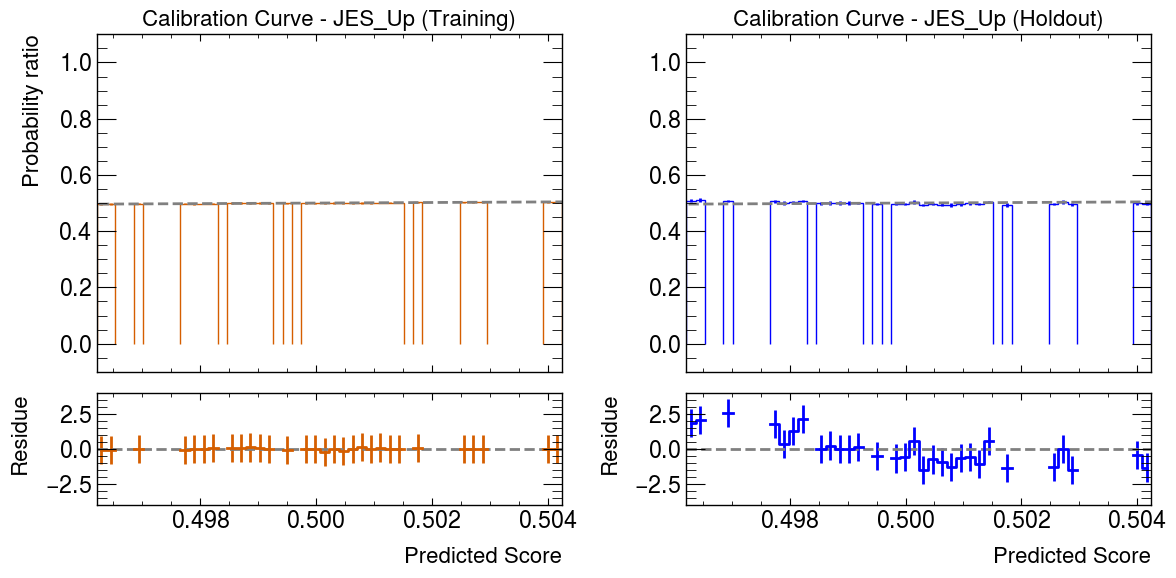

<Figure size 800x600 with 0 Axes>

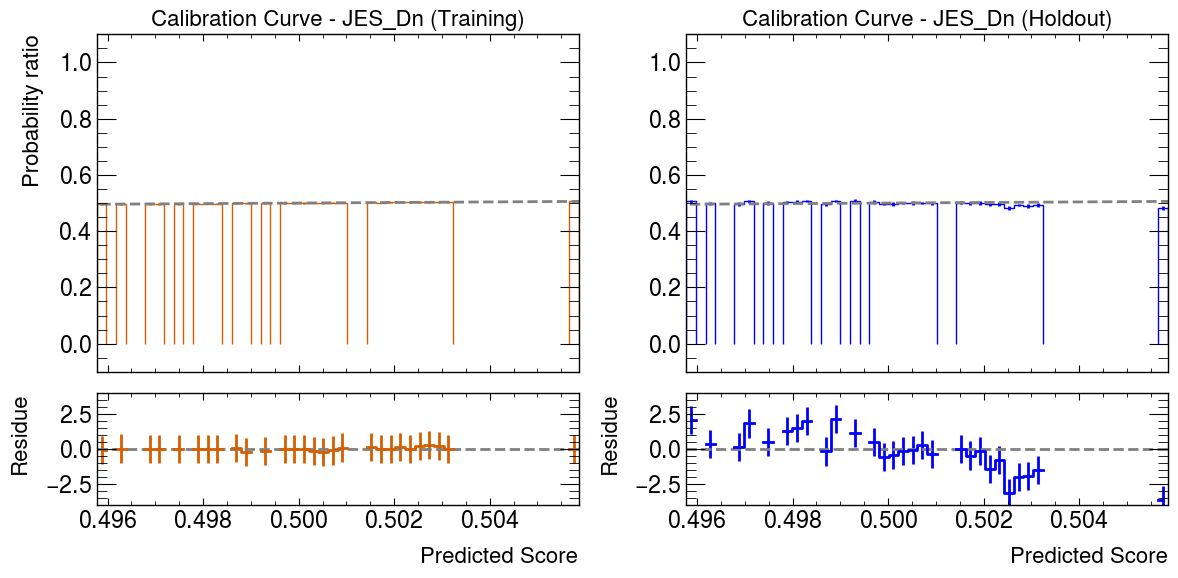

<Figure size 800x600 with 0 Axes>

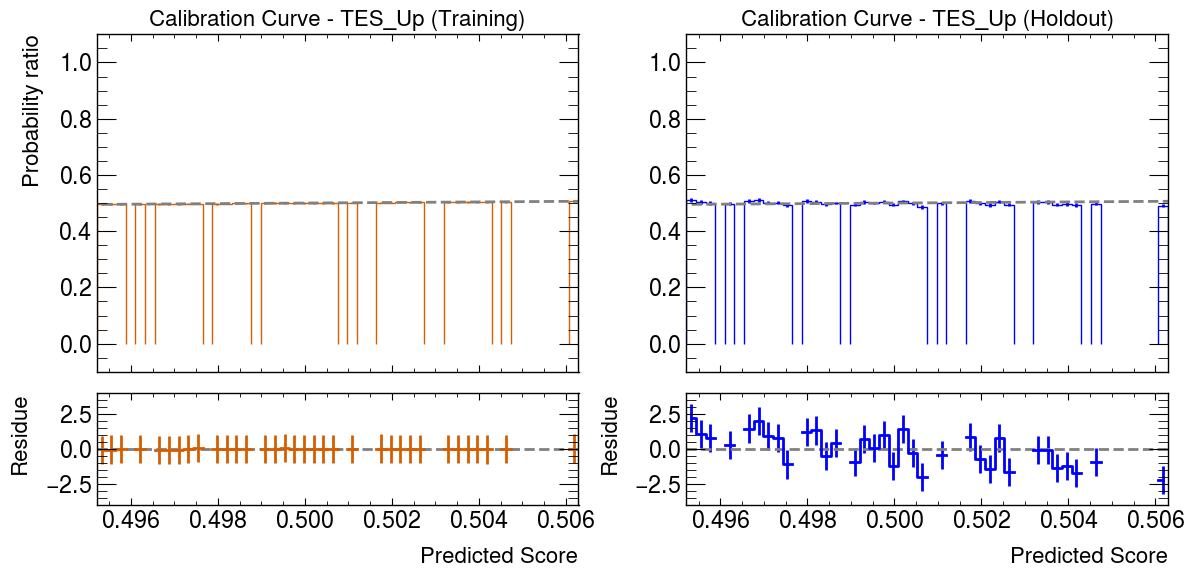

<Figure size 800x600 with 0 Axes>

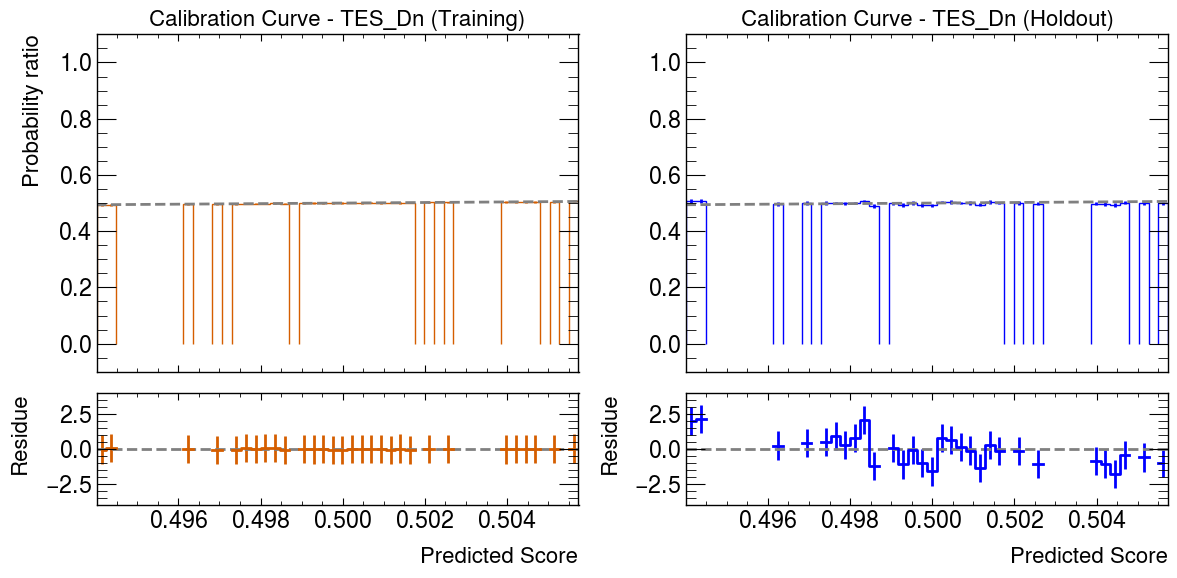

<Figure size 800x600 with 0 Axes>

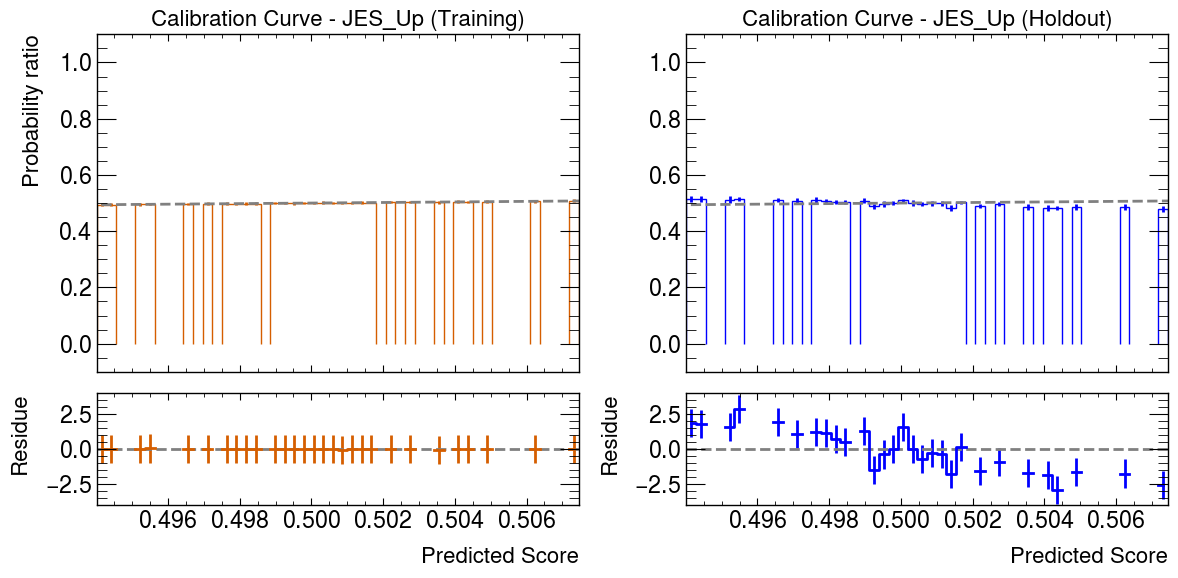

<Figure size 800x600 with 0 Axes>

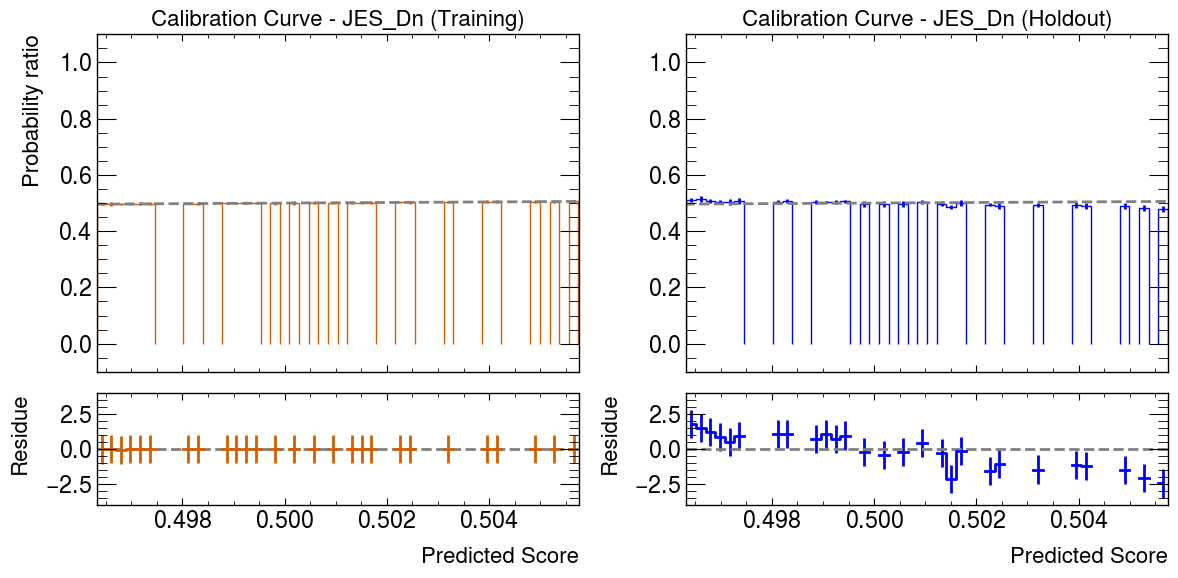

<Figure size 800x600 with 0 Axes>

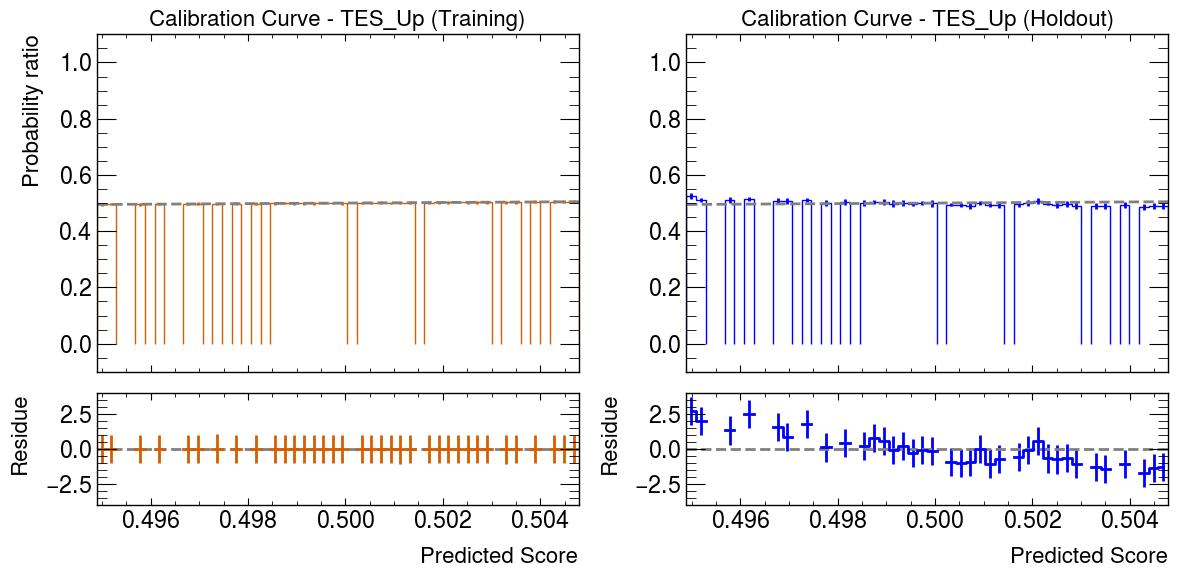

<Figure size 800x600 with 0 Axes>

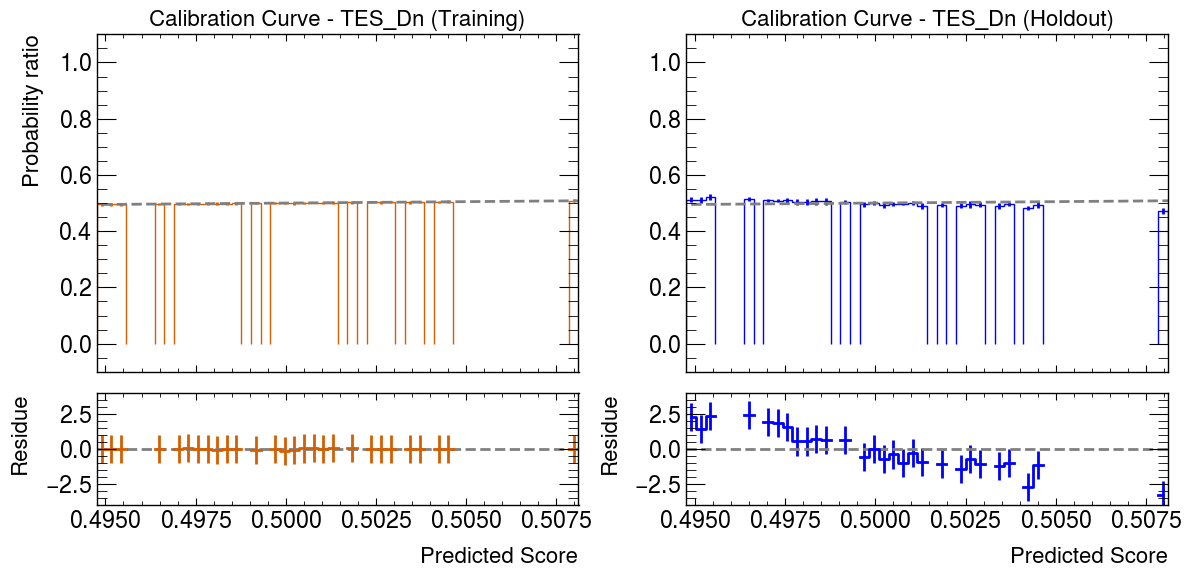

<Figure size 800x600 with 0 Axes>

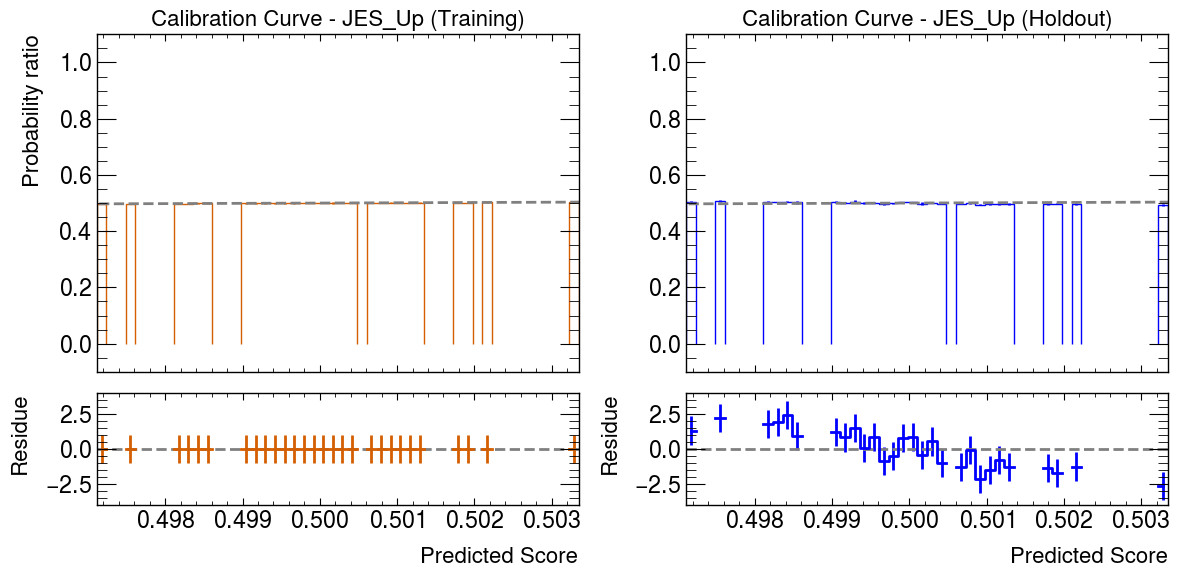

<Figure size 800x600 with 0 Axes>

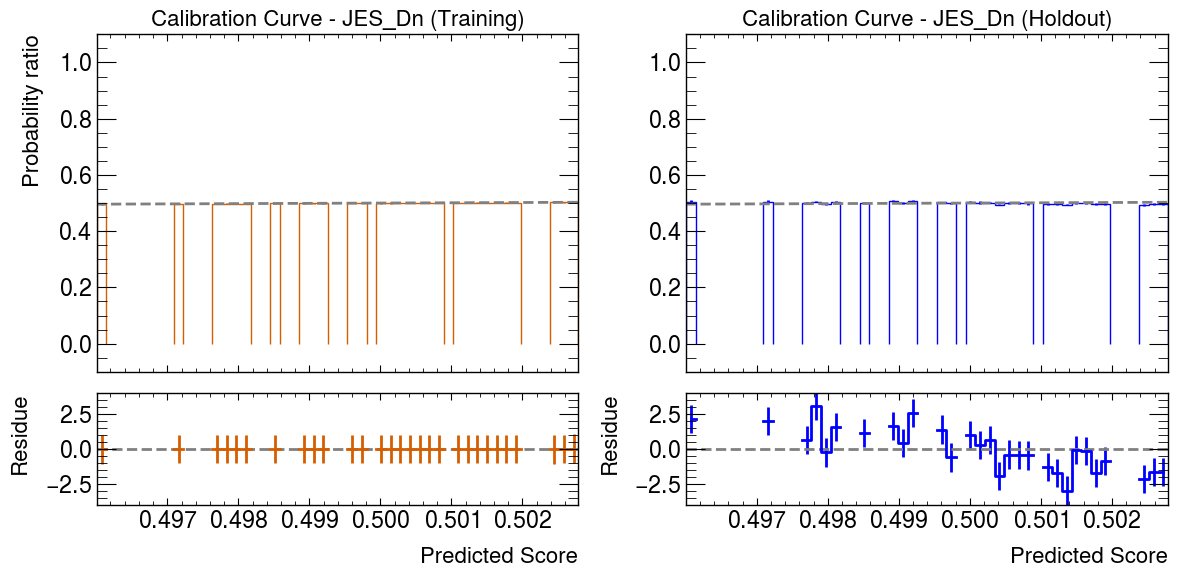

<Figure size 800x600 with 0 Axes>

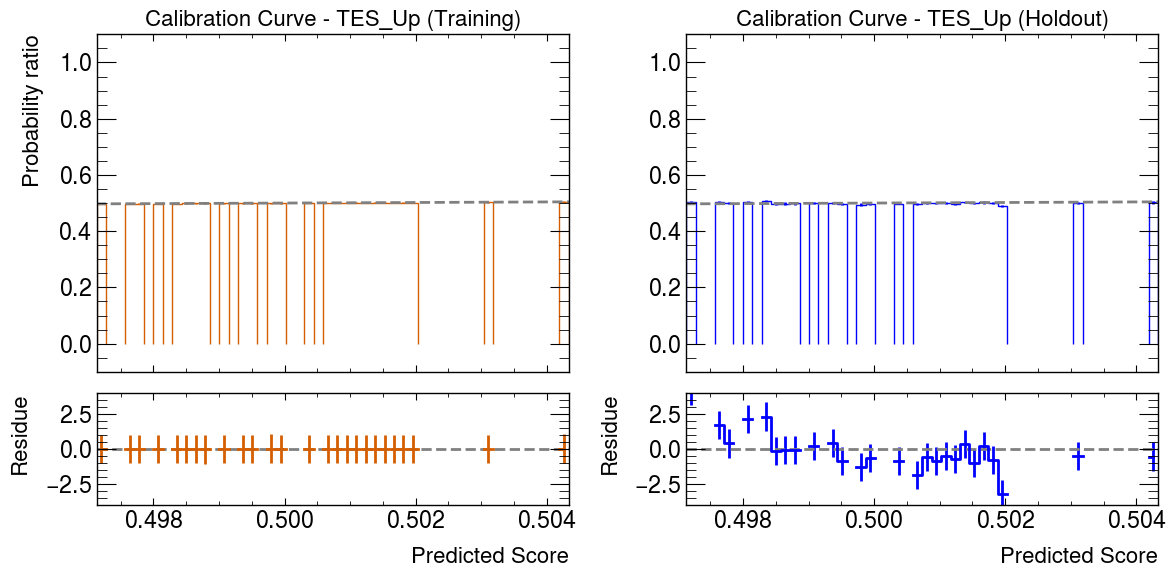

<Figure size 800x600 with 0 Axes>

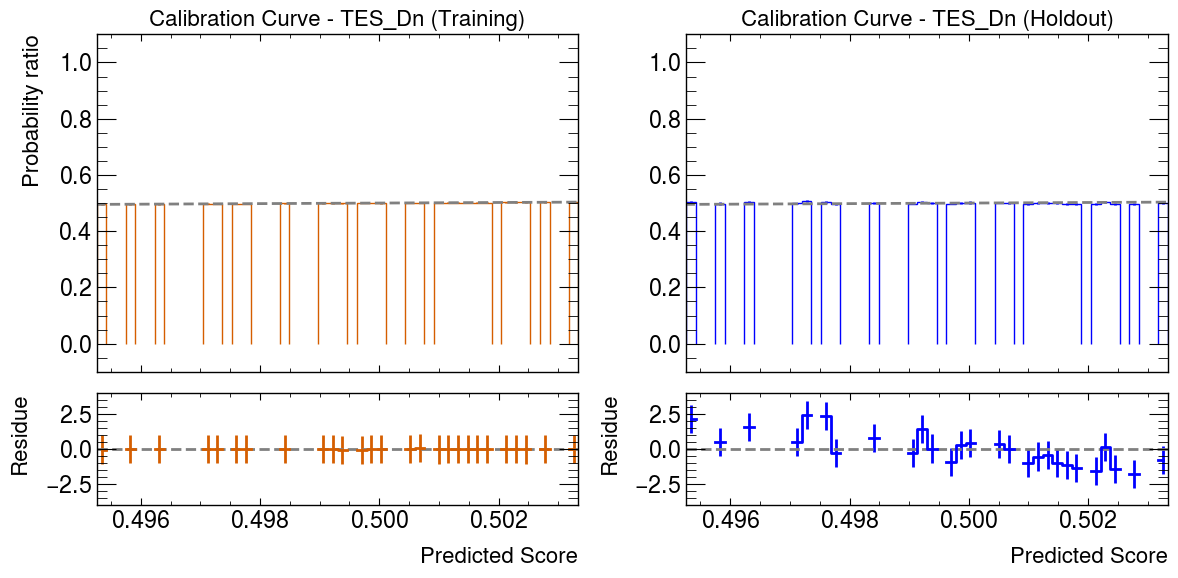

<Figure size 800x600 with 0 Axes>

In [38]:
for process in config_nsbi.get_basis_samples():
    
    for dict_syst in config_nsbi.config["Systematics"]:

        if (process not in dict_syst["Samples"]) or (dict_syst["Type"] != "NormPlusShape"): continue

        syst = dict_syst["Name"]

        for direction in ["Up", "Dn"]:
            samples_to_train = config_nsbi.get_samples_in_syst_for_training(syst, direction)

            num_bins_cal = 50
            NN_training_syst_process[process][syst][direction].make_calib_plots(nbins=num_bins_cal, observable='score')
            # NN_training_mix_model[process_type].make_calib_plots(nbins=num_bins_cal, observable='llr')
    

## Density ratio reweighting closure tests
  
  Despite having a well-calibrated output and thus a robust probabilistic interpretation, the trained density ratios might not capture the full multi-dimensional event information $x$. In other words, the NNs might still be biased estimators of the optimal score function, as defined in the CARL paper (link).

  The next diagnostic involves verifying the following equality using 1D projections of $x$:

  $$\frac{p_\text{c}(x|\alpha_p^\pm)}{p_\text{c}(x)} \times p_\text{c}(x) \sim p_\text{c}(x|\alpha_p^\pm)$$

  We can do this one-by-one for all the observables used to model the density ratios, and also possibly the observables not used directly in the training but can still be well-estimated due to the NN learning the right physics.

Validation ratio: ztautau vs JES_Up


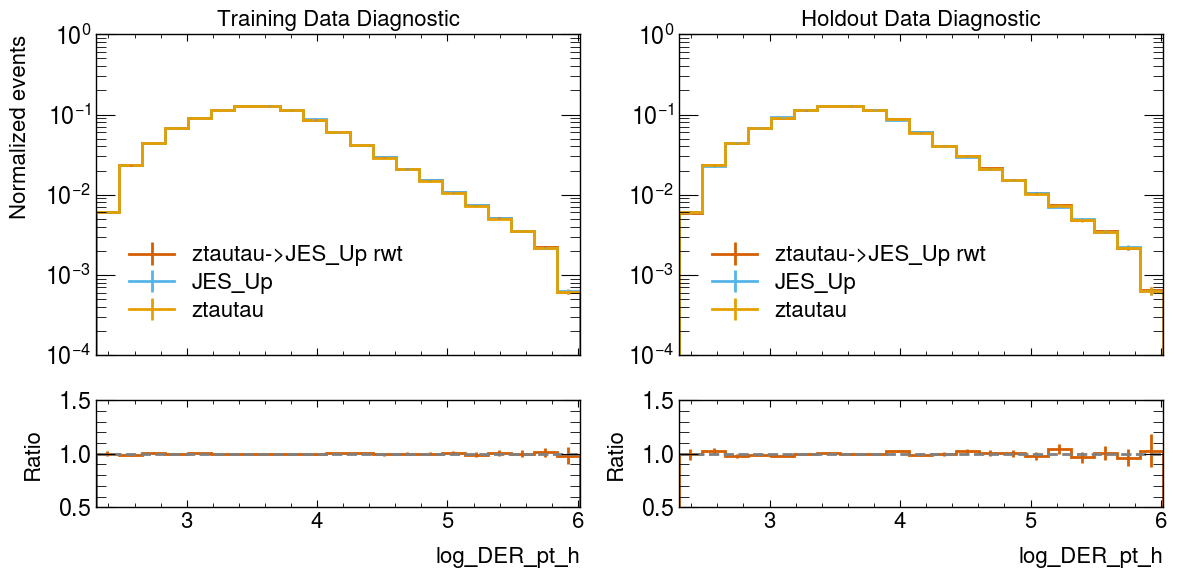

Validation ratio: ztautau vs JES_Dn


<Figure size 800x600 with 0 Axes>

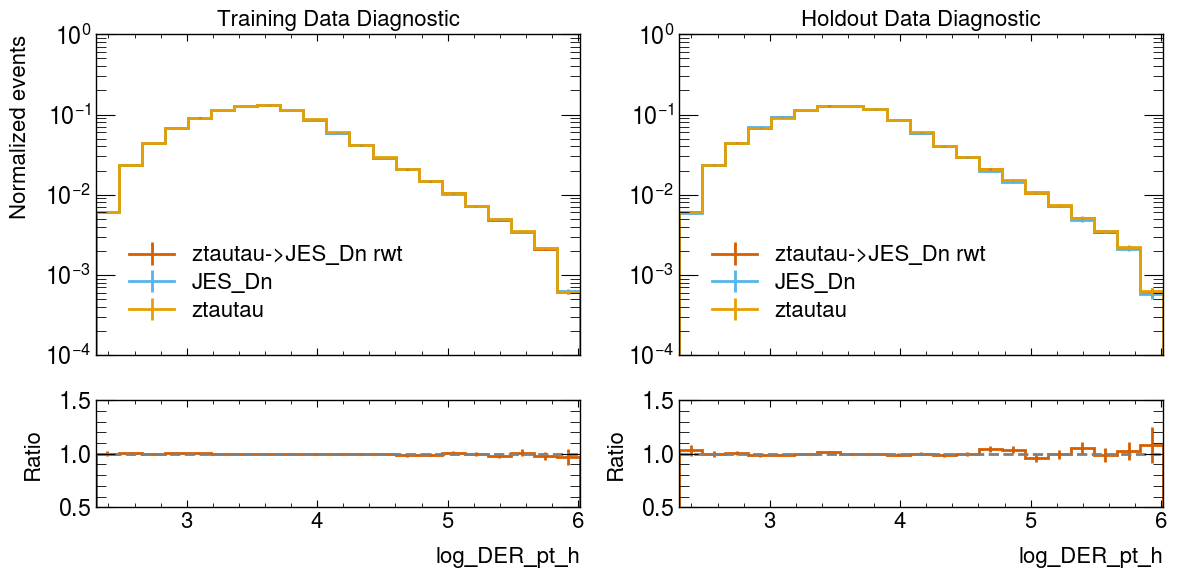

Validation ratio: ztautau vs TES_Up


<Figure size 800x600 with 0 Axes>

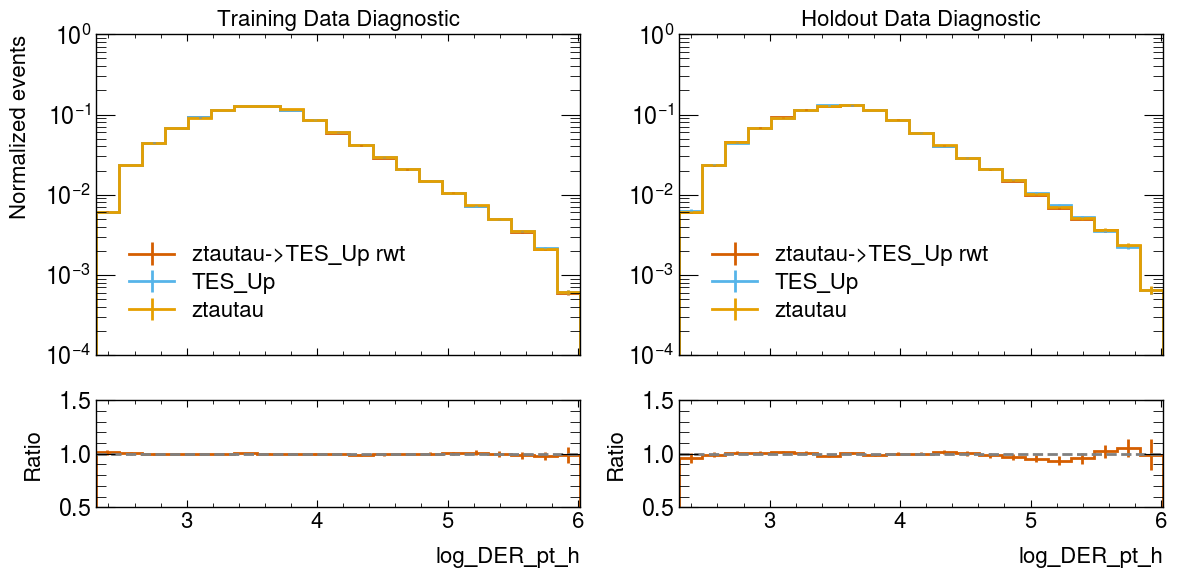

Validation ratio: ztautau vs TES_Dn


<Figure size 800x600 with 0 Axes>

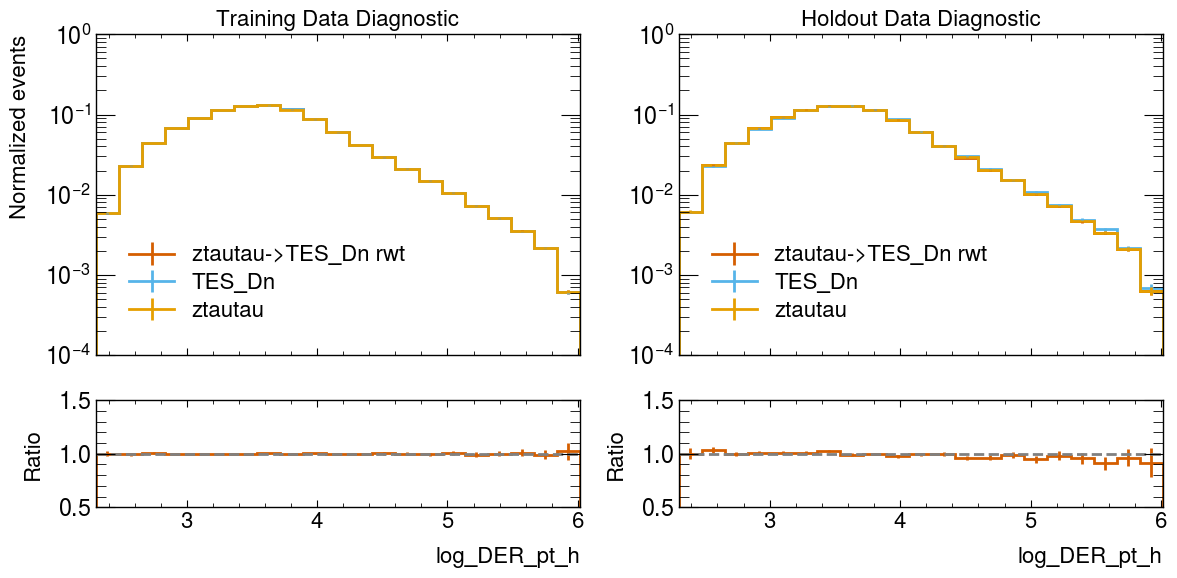

Validation ratio: ttbar vs JES_Up


<Figure size 800x600 with 0 Axes>

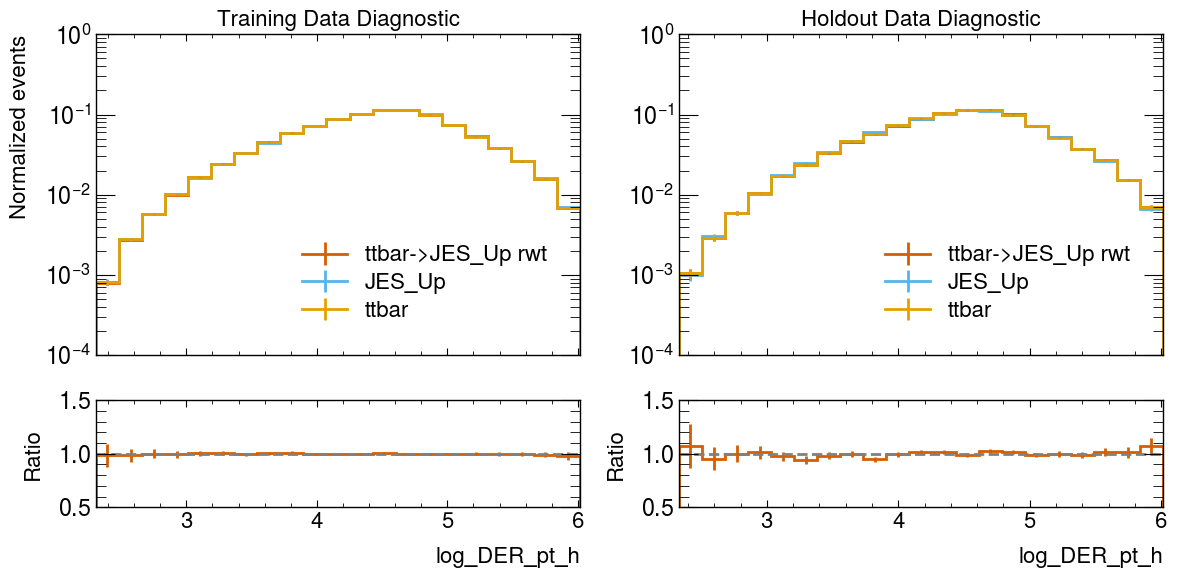

Validation ratio: ttbar vs JES_Dn


<Figure size 800x600 with 0 Axes>

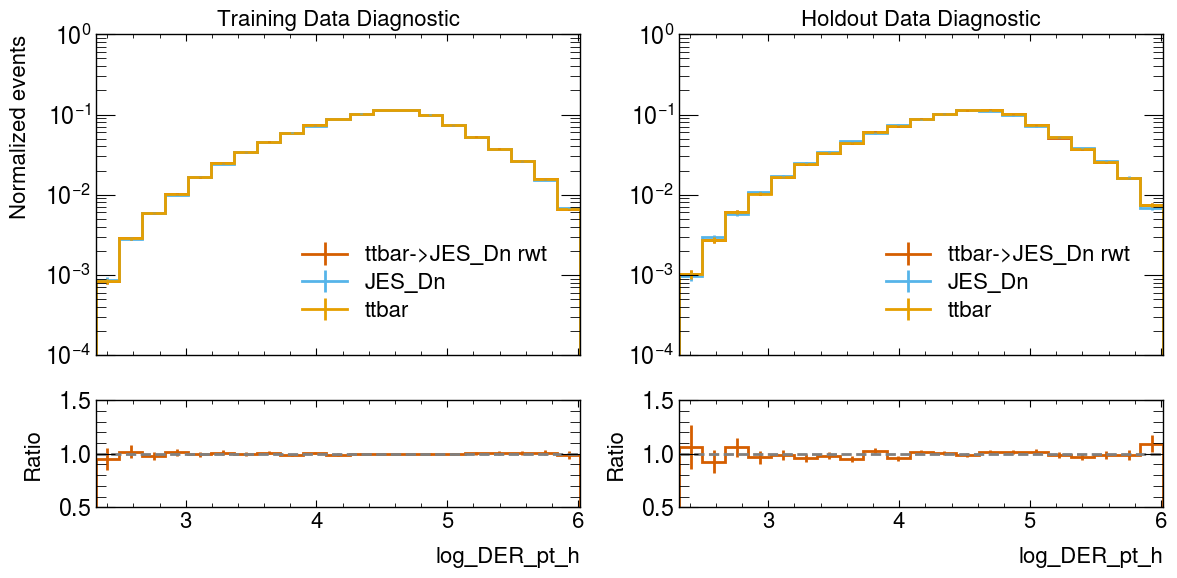

Validation ratio: ttbar vs TES_Up


<Figure size 800x600 with 0 Axes>

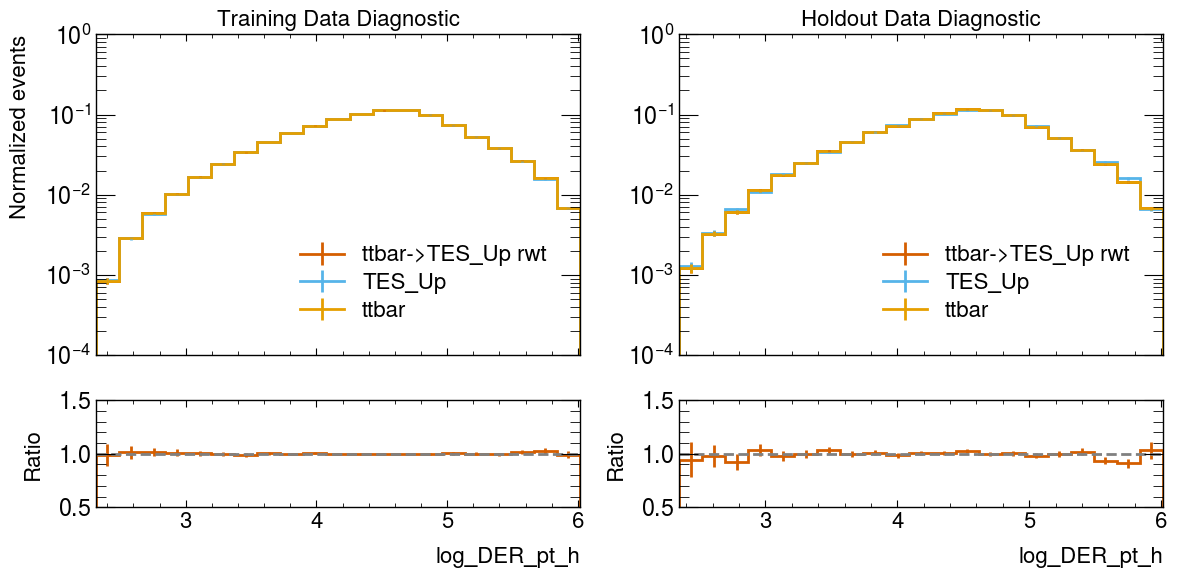

Validation ratio: ttbar vs TES_Dn


<Figure size 800x600 with 0 Axes>

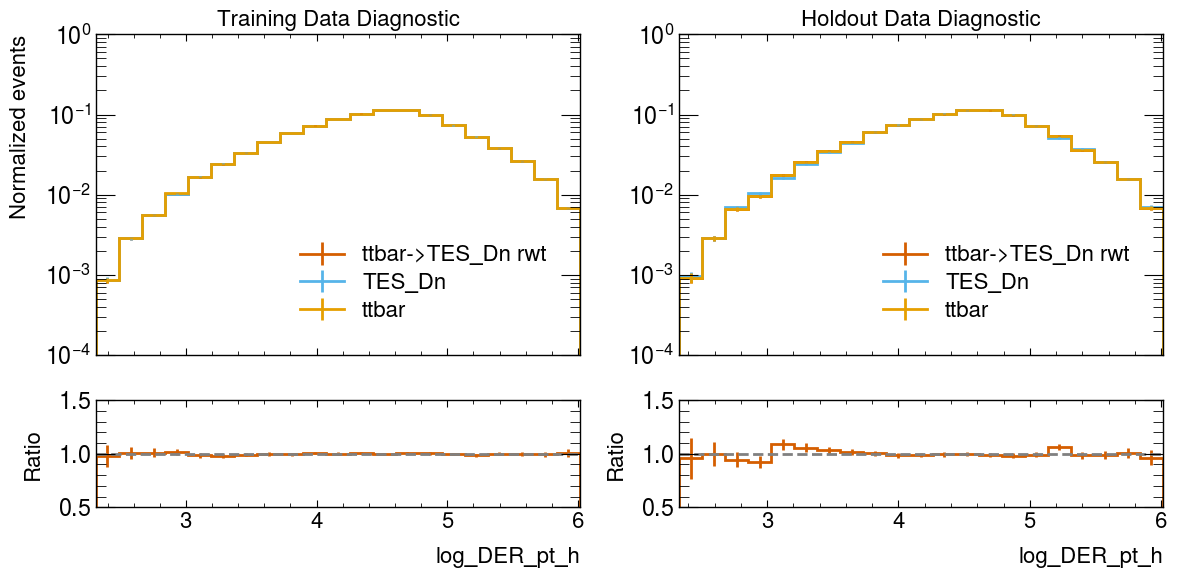

Validation ratio: htautau vs JES_Up


<Figure size 800x600 with 0 Axes>

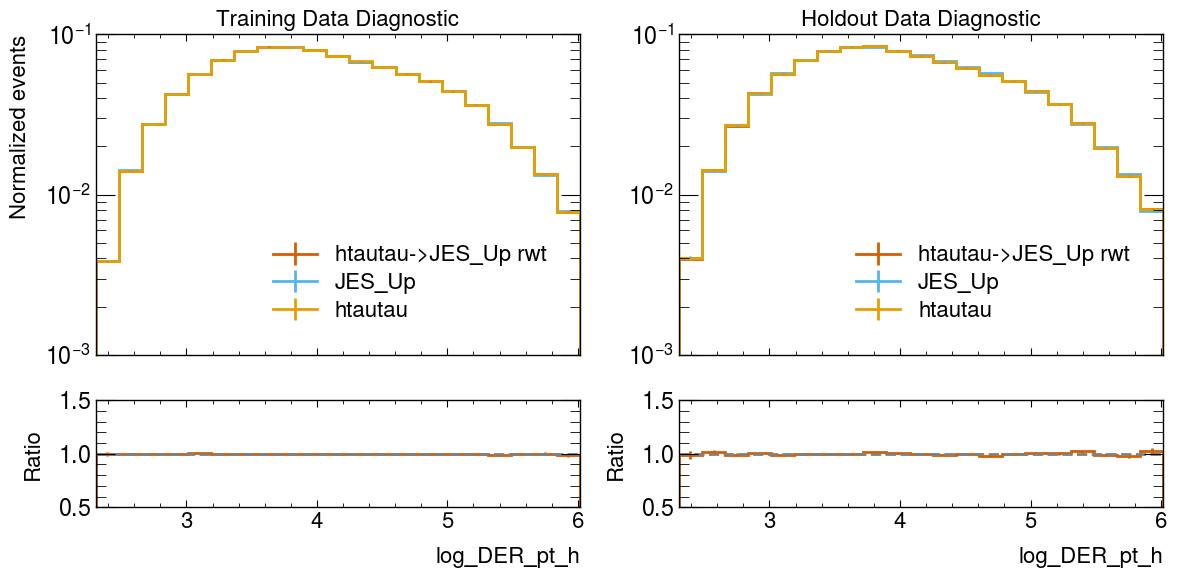

Validation ratio: htautau vs JES_Dn


<Figure size 800x600 with 0 Axes>

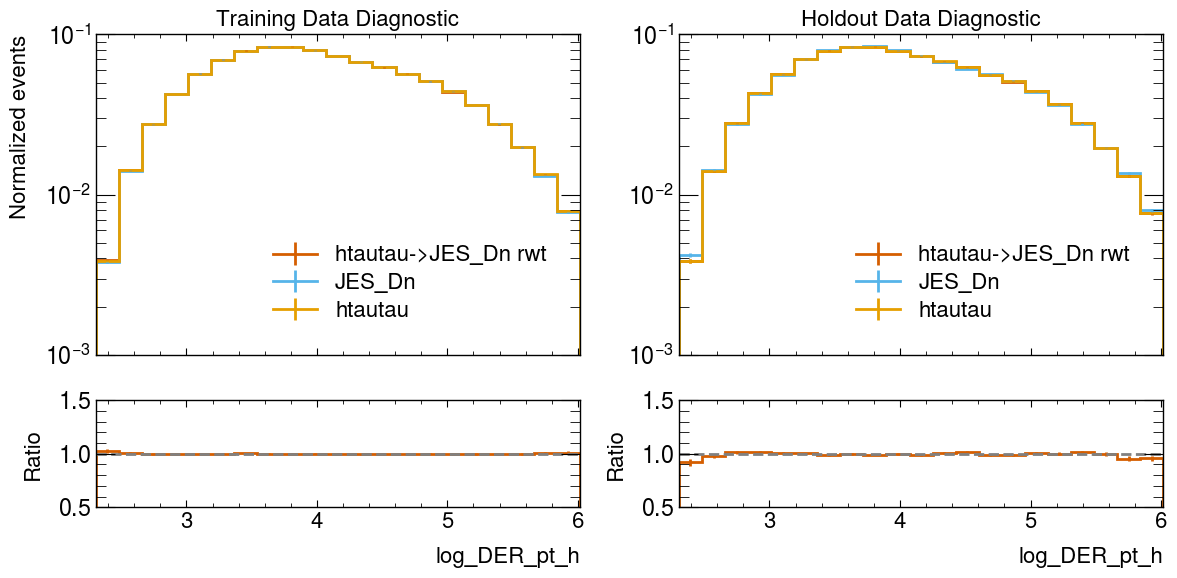

Validation ratio: htautau vs TES_Up


<Figure size 800x600 with 0 Axes>

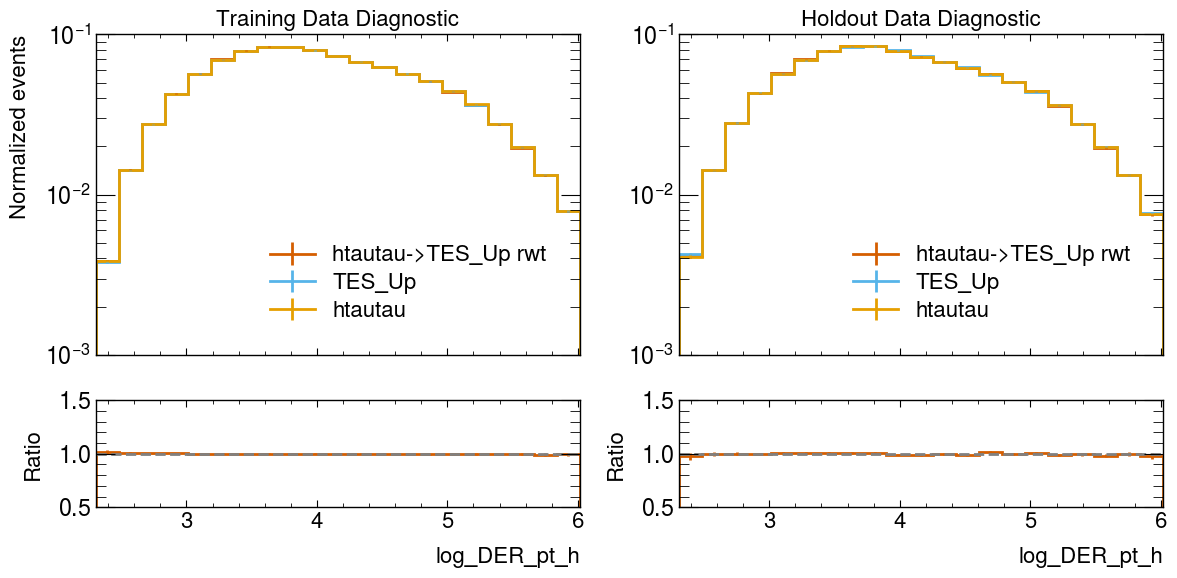

Validation ratio: htautau vs TES_Dn


<Figure size 800x600 with 0 Axes>

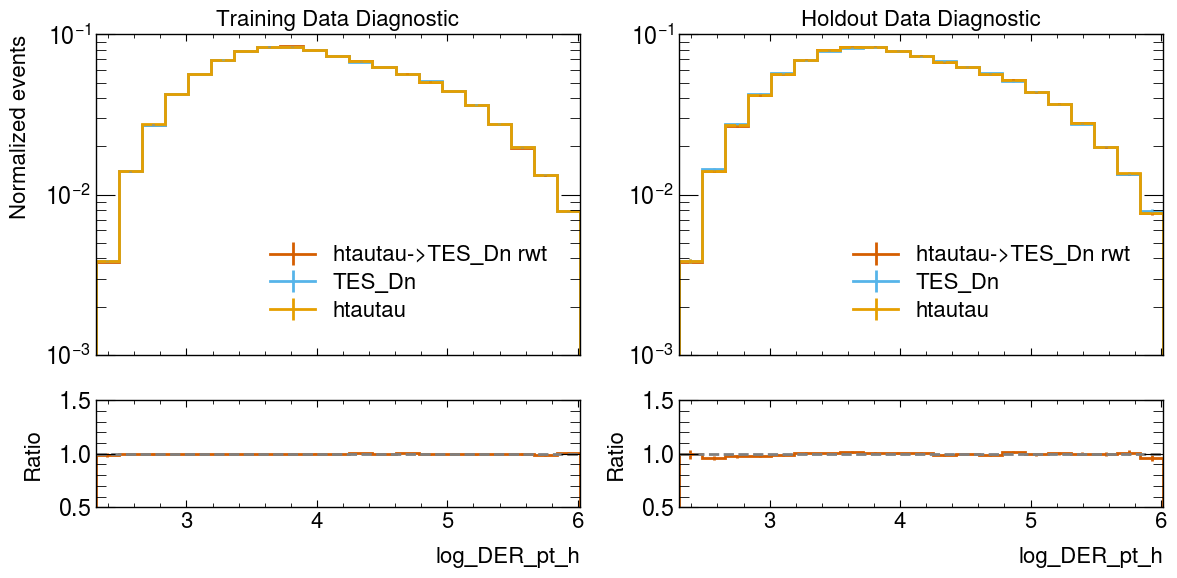

<Figure size 800x600 with 0 Axes>

In [41]:
for process in config_nsbi.get_basis_samples():
    
    for dict_syst in config_nsbi.config["Systematics"]:

        if (process not in dict_syst["Samples"]) or (dict_syst["Type"] != "NormPlusShape"): continue

        syst = dict_syst["Name"]

        for direction in ["Up", "Dn"]:
            samples_to_train = config_nsbi.get_samples_in_syst_for_training(syst, direction)

            syst_key_name = f"{syst}_{direction}"
            if syst_key_name not in dataset_SR_dict: continue

            print(f"Validation ratio: {process} vs {syst_key_name}")

            variables_to_plot=['log_DER_pt_h'] # The 1D variable for reweighting closure
            yscale_type='log'
            num_bins_plotting=21
            NN_training_syst_process[process][syst][direction].make_reweighted_plots(variables_to_plot, yscale_type, num_bins_plotting)
